Take basic data preparation from the `01Middle_income_structural.ipynb`
But produce a clean set of visualizations: 

## Data load and prep

In [1]:
import os
import re #regular expressions
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pypandoc # results tables
import geopandas as gpd #choropleth plot
from statsmodels.stats.proportion import proportions_ztest
from collections import Counter
from graphviz import Source #to render Graphviz diagrams
from matplotlib.patches import Patch
from wto_format_helpers import save_table
from wto_format_helpers import create_regression_table_html

In [2]:
## check working directory, set project paths
# Get current working directory
cwd = Path(os.getcwd())

# Define paths for project:
datapath = cwd / "../data"
FIGPATH = cwd / "../figures"


In [3]:
data2 = pd.read_csv('../data/wtoCTDSpeakerParagraphMto117_varyingInc.csv')

In [4]:
## Overall summary statistics:
print(data2.shape) ##11,737
print(data2['meetingno'].max()) #117
print(data2['year'].min()) #1995
print(data2['year'].max()) #2022
print(data2.columns)

(11737, 23)
117
1995
2022
Index(['Unnamed: 0', 'paranum', 'paratext', 'doc', 'firstent', 'ents',
       'speaker.change', 'isagenda', 'minutes.meta', 'behalf', 'date', 'year',
       'meetingno', 'numdate', 'people', 'codes', 'Freq', 'country', 'region',
       'inc_level_abbrev', 'pres.speaker', 'pid', 'dynamic_income'],
      dtype='object')


In [5]:
## States is all speaker-paragraphs that are not tagged wit a non-state flag
states = data2.loc[(data2['inc_level_abbrev'] != 'NONST') &
                   (data2['inc_level_abbrev'].notna())]

states[states['dynamic_income']=="Aggregated"]['pres.speaker'].unique() ## Verify "Aggregated" = EU
states.loc[states['dynamic_income'] == 
           "Aggregated", 'dynamic_income'] = "High income" # can undo if pref to keep AGG


In [6]:
del data2 ## only keep states data

In [7]:
## Descriptive statistics:
# (data introduction paragraph)
print(states.shape) #(5660, 24)
print(states['country'].nunique()) #126
print(states['inc_level_abbrev'].value_counts())


(5660, 23)
126
inc_level_abbrev
HIC    1775
LMC    1408
LIC    1014
UMC     904
AGG     559
Name: count, dtype: int64


## Data preparation flow

One for publication, longer for Githut

(here graphviz, exported via: `Source(dot_code).render('WTO_DataPrep', format='svg', cleanup=True`)
)

In [8]:
print(states.head)

<bound method NDFrame.head of        Unnamed: 0  paranum                                           paratext  \
6               6      7.0  7.      The representative of Tunisia said tha...   
8               8      9.0  9.      The representative of Poland said that...   
9               9     10.0  10.    The representative of the United States...   
10             10     11.0  11.     The representative of Argentina querie...   
11             11     12.0  12.     The representative of Japan thought th...   
...           ...      ...                                                ...   
11728       11728    103.0  103. The representative of Cameroon said that,...   
11729       11729    104.0  104. The representative of Bangladesh said tha...   
11730       11730    105.0  105. The representative of the Russian Federat...   
11731       11731    106.0  106. The representative of Mauritius said that...   
11732       11732    107.0  107. The representative of the European Union ...  

## Plots for expectation 1: 
Participation and leadership capability

In [9]:
# Group by meeting and income level, count speaker-turns
grouped = states.groupby(['year', 'dynamic_income']).size().reset_index(name='speaker_turns')

# Compute total speaker-turns per meeting
total_per_meeting = grouped.groupby('year')['speaker_turns'].transform('sum')

# Calculate percentage
grouped['percentage'] = grouped['speaker_turns'] / total_per_meeting * 100
grouped['percentage'] = grouped['percentage'].round(3)
                    

In [10]:
#pivot = data object with income levels as columns
pivot = grouped.pivot(index='year', 
                      columns='dynamic_income',
                      values='percentage').fillna(0)
   

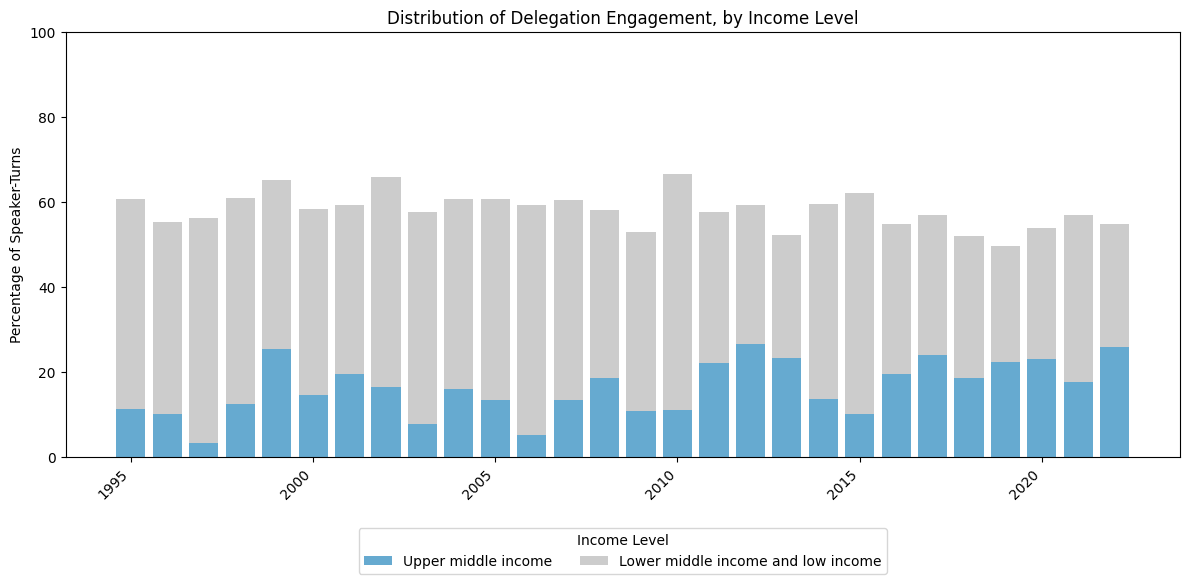

In [11]:
# Plot 1: Distribution of delegation engagement UMC vs lower income levels:
# omitting high incomes countries

grayscale_colors = {
#    "High income": "#111111",         # near black
    "Upper middle income": "#0072B2",
    "Lower middle income": "#AAAAAA",
    "Low income": "#AAAAAA"
}

income_order2 = ["Upper middle income", 
                "Lower middle income", "Low income"]

# Ensure the pivot DataFrame is in the correct column order
pivot = pivot.reindex(columns=income_order2).fillna(0)

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))

# Start stacked bars at 0
bottom = pd.Series([0] * len(pivot), index=pivot.index)

# Plot stacked bars
for income_level in income_order2:
    if income_level in pivot.columns:
        ax.bar(
            pivot.index,
            pivot[income_level],
            bottom=bottom,
            alpha=0.6,
            linewidth=0,
            color=grayscale_colors.get(income_level, "#333333")
        )

        # Update stacking baseline
        bottom += pivot[income_level]

# Custom legend handles
legend_handles = [
    Patch(
        facecolor="#0072B2",
        alpha=0.6,
        label="Upper middle income"
    ),
    Patch(
        facecolor="#AAAAAA",
        alpha=0.6,
        label="Lower middle income and low income"
    )
]

# Final formatting
ax.set_ylabel("Percentage of Speaker-Turns")
ax.set_title("Distribution of Delegation Engagement, by Income Level")

ax.legend(
    handles=legend_handles,
    title="Income Level",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

plt.tight_layout()

fig_file = FIGPATH / 'dist_engagement.png'
plt.savefig(fig_file, dpi=300)

plt.show()

t-tests supporting in-text claim that at the end of the time period, upper-middle-income states are participating more frequently than in early years, they still are not participating more frequently than states at lower income-levels.

Test: quantify the growing role of middle income countries using distributional tests of their activities across time. [MJF: NB that 2009 is the midpoint of our data, which spans 27 yaers from 1995- 2022. Visually we observe a change in activity.]

Magnitude of the effect: Cohen's d. Quantifies the standarized difference between two means.  Benchmarks sugest that a small difference is ~0.2, a medium is ~0.5, and a large effecet is ~0.8, Sign indicates direction, with a positive value meaning that the first group had a larger mean Cohen's d is independence of sample size


In [12]:
## data object used: pivot = state subset with income level as columns
from scipy.stats import ttest_ind

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = (((n1 - 1)*a.std()**2 + (n2 - 1)*b.std()**2) / (n1 + n2 - 2))**0.5
    return (a.mean() - b.mean()) / pooled_std

incs = ["Upper middle income", "Lower middle income", "Low income"]

tt_results = []
for group in incs:
        # Get pre/post data for each group; fit vi 2009, the midpoint
    pre_vals = pivot.loc[pivot.index < 2009, group].dropna()
    post_vals = pivot.loc[pivot.index >= 2009, group].dropna()
    
    # Run Welch's t-test (doesn't assume equal variances)
    t_stat, p_val = ttest_ind(pre_vals, post_vals, equal_var=False)

    # Cohen's d for effect size:
    cd = cohens_d(pre_vals, post_vals)

    tt_results.append({
        'income_group': group,
        'pre_2007_mean': pre_vals.mean().round(3),
        'post_2007_mean': post_vals.mean().round(3),
        't_stat': t_stat.round(3),
        'p_value': p_val.round(3),
        'cohens_d': cd.round(3)
    })

tt_df = pd.DataFrame(tt_results)

In [13]:
print(tt_df)

          income_group  pre_2007_mean  post_2007_mean  t_stat  p_value  \
0  Upper middle income         13.435          19.239  -2.663    0.013   
1  Lower middle income         22.690          28.974  -2.610    0.016   
2           Low income         23.808           8.185   7.903    0.000   

   cohens_d  
0    -1.007  
1    -0.987  
2     2.987  


Heatmap of specific activity patterns: 
The spotlighted countries were identified by in a heatmap of activities of all UMC and LMC countries

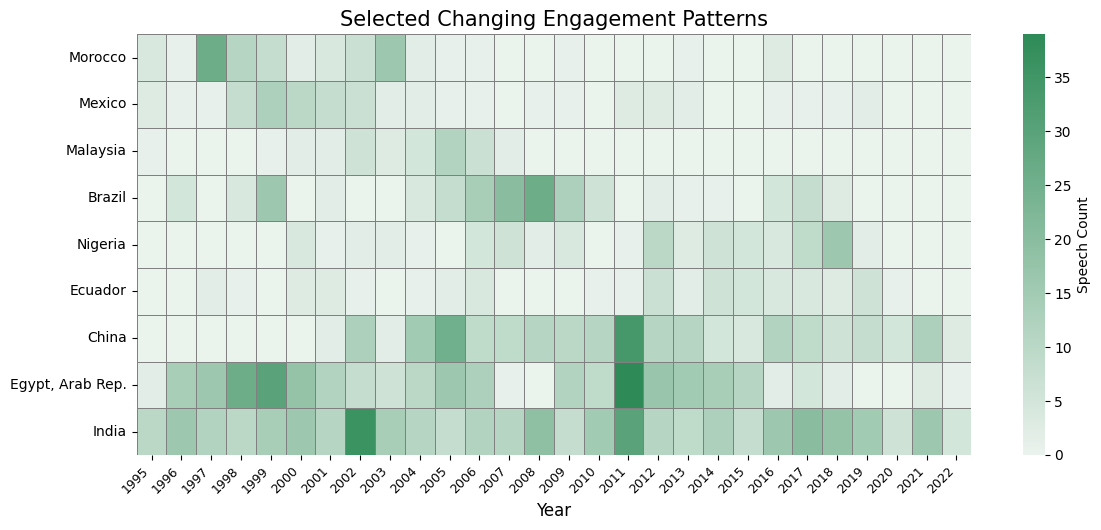

In [14]:
## Heatmap and maps:
activity_shift = (
    states
    .groupby(['country', 'year'])
    .size()
    .reset_index(name='speech_count')
)

# --- Step 2: focus on selected countries ---
interesting_countries = [
    'Morocco', 'Mexico', 'Malaysia',  # early
    'Brazil',                         # middle
    'Nigeria', 'Ecuador',   # late
    'China',          
    'Egypt, Arab Rep.', 
    'India', 
]

activity_df_subset = activity_shift[
    activity_shift['country'].isin(interesting_countries)
]

# --- Step 3: pivot to wide form (be sure to include values='speech_count') ---
heatmap_data = (
    activity_df_subset
    .pivot(index='country', 
           columns='year', 
           values='speech_count')
    .fillna(0)
    .loc[interesting_countries]  # preserve chosen order
)

# --- Step 4 (optional normalization) ---
# heatmap_data = heatmap_data.div(heatmap_data.max(axis=1), axis=0)      # scale 0–1 within country
# heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)*100  # share of total by year

# --- Step 5: plot ---

cmapplot = sns.light_palette("seagreen", as_cmap=True)
                         
plt.figure(figsize=(12, 0.6 * len(heatmap_data)))  # dynamic height
ax = sns.heatmap(
    heatmap_data,
    cmap= cmapplot,
    linewidths=0.4,
    linecolor='gray',
    annot=False,       # ✅ no numbers in boxes
    cbar_kws={'label': 'Speech Count'}
)

# --- Style tweaks ---
ax.set_title('Selected Changing Engagement Patterns', fontsize=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(FIGPATH / 'selected_changing_engagement_patterns.png', dpi=300)
plt.show()



World contribution density maps-- this is our replacement for the all activity heatmap:

In [15]:
#map:
# For offline replication, download the shapefile once and store locally:
#   https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
# Save the zip to:  data/shapefiles/ne_110m_admin_0_countries.zip

shapefile_local = cwd / "../data/shapefiles/ne_110m_admin_0_countries.zip"
shapefile_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

if shapefile_local.exists():
    world = gpd.read_file(shapefile_local)
else:
    print("Local shapefile not found — downloading from Natural Earth (requires internet).")
    print(f"To avoid this for replication, save the zip to: {shapefile_local}")
    world = gpd.read_file(shapefile_url)


Local shapefile not found — downloading from Natural Earth (requires internet).
To avoid this for replication, save the zip to: /Users/Promachos/Dropbox (Personal)/WTO-Github/WTO-DataRelease/code/../data/shapefiles/ne_110m_admin_0_countries.zip


In [16]:
# Rename world map column for convenience:
for candidate in ['name', 'ADMIN', 'NAME_LONG']:
    if candidate in world.columns:
        world = world.rename(columns={candidate: 'country'})
        break

In [17]:
## Subset states data for only relevant income tiers (LMC + UMC)
states_mid = states[states['inc_level_abbrev'].isin(['UMC', 'LMC'])].copy()

# Count speaking turns per country-year
activity_df_mid = (## codes is ISO3
    states_mid.groupby(['codes', 'year', 'inc_level_abbrev'])
    .size()
    .reset_index(name='speech_count')
)

# End bins at 2022
activity_df_mid['year_bin'] = (activity_df_mid['year'] // 5) * 5
activity_df_mid = activity_df_mid[activity_df_mid['year'] <= 2022]

# recompute label safely up to 2022
activity_df_mid['bin_label'] = (
    activity_df_mid['year_bin'].astype(str) + '–' +
    (activity_df_mid['year_bin'] + 4).clip(upper=2022).astype(str)
)

activity_bin_mid = (
    activity_df_mid
    .groupby(['codes', 
              'bin_label',
                'inc_level_abbrev'], as_index=False)['speech_count']
    .sum()
)

transitions = (
    activity_bin_mid.groupby('codes')['inc_level_abbrev']
    .nunique()
    .reset_index(name='n_levels')
)
transition_countries = transitions.loc[transitions['n_levels'] > 1, 'codes']
activity_bin_mid['is_transition'] = activity_bin_mid['codes'].isin(transition_countries)

In [ ]:
world.columns

: 

In [18]:
# Make names consistent:

fixnames = {
    'The_united_states': 'United States of America',
    'Russian_federation': 'Russia',
    'Viet_nam': 'Vietnam',
    'Czech_republic': 'Czechia',
}

## But actually use the iso3 codes:
activity_bin_mid['iso3'] = (
    activity_bin_mid['codes']
    .replace(fixnames)
)

## Map ISO3 to the verion in the shapefile:
world_clean = world.copy()

for col in ['ISO_A3', 'ADM0_A3', 'SOV_A3']:
    if col in world_clean.columns:
        world_clean = world_clean.rename(columns={col: 'iso3'})
        break

#world_clean = world_clean[['iso3', 'country', 'geometry']].copy()
world_clean = world_clean[['iso3', 'geometry']].copy()


# drop or patch odd pseudo-codes
world_clean['iso3'] = world_clean['iso3'].replace({
    'SAH': 'ESH',   # Western Sahara → ISO code
    'US1': 'USA',   # United States
    '-99': None     # undefined
})

In [20]:
# Merge data and shapefile:
merged_mid = world_clean.merge(activity_bin_mid, on='iso3', how='left')
merged_mid['speech_count'] = merged_mid['speech_count'].fillna(0)

activity_bin_mid['bin_total'] = (
    activity_bin_mid.groupby('bin_label')['speech_count'].transform('sum')
)

activity_bin_mid['speech_pct'] = (
    100 * activity_bin_mid['speech_count'] / activity_bin_mid['bin_total']
)

In [21]:
# Base plot:
def plot_choropleths(activity_bin_df, world_gdf, title_prefix="UMC + LMC"):
    """
    Draws global choropleths by 5-year bins, shading countries by speech_pct (percent share).
    """

    # Merge with world map
    merged = world_gdf.merge(activity_bin_df, on='iso3', how='left')
    merged['speech_pct'] = merged['speech_pct'].fillna(0)

    # Consistent color scaling across panels
    vmax = merged['speech_pct'].max()
    bins = sorted(activity_bin_df['bin_label'].unique())
    ncols = 2
    nrows = (len(bins) + ncols - 1) // ncols

    # Create figure
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(16, 9),
        subplot_kw={'aspect': 'equal'}
    )
    axes = axes.flatten()

    for ax, bin_label in zip(axes, bins):
        # Draw global outline
        world_gdf.plot(ax=ax, color='none', edgecolor='lightgray', linewidth=0.4)

        # Overlay active countries

        cmapplot = sns.light_palette("seagreen", as_cmap=True)


        data = merged[merged['bin_label'] == bin_label]
        data.plot(
            column='speech_pct',    # <-- key change here
            cmap=cmapplot,
            linewidth=0.3,
            edgecolor='gray',
            vmin=0, vmax=vmax,
            ax=ax
        )

        ax.set_title(f"{bin_label}", fontsize=11)
        ax.axis('off')

    # Hide unused panels
    for ax in axes[len(bins):]:
        ax.axis('off')

    # Unified layout
    plt.suptitle(f"Share of UMC + LMC Speaking Turns by 5-Year Interval", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig(FIGPATH / 'map_mc_speaking_turns.png', dpi=300)
    plt.show()

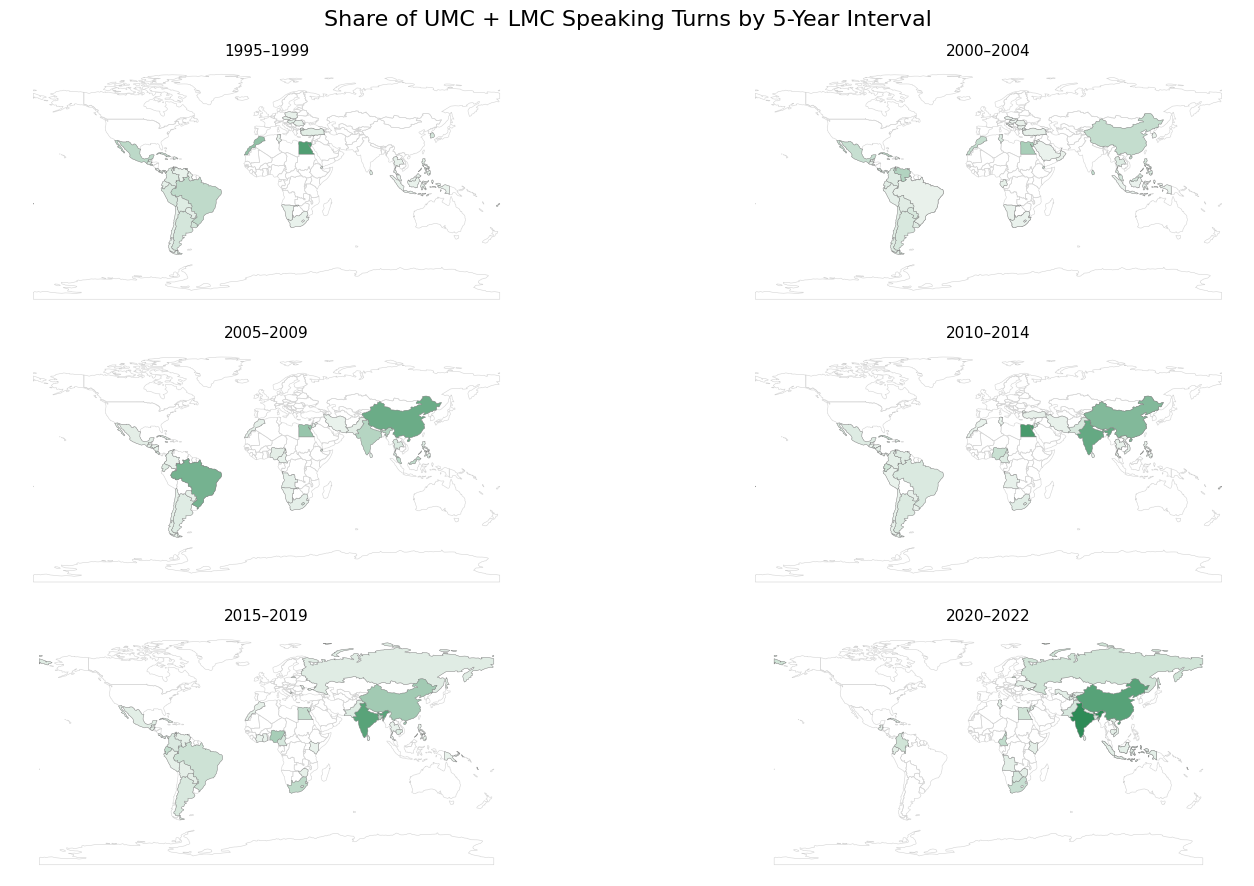

In [22]:
plot_choropleths(activity_bin_mid, world_clean, title_prefix="LMC + UMC Countries")

## Supporting statement about "squeezing out" of LMCs

Operationalize "squeezing out" via: X % of countries reponsible for 80% of LIC contribution.
Approach: group by income level and country; count the number of speakers 

Plot of concentration, in the sense of the number of countries that make up 80% of the participation of a given income level. 

In [23]:
threshold = 0.8

# 1. aggregate
grouped_all = (
    states
    .groupby(['year', 'dynamic_income', 'country'], as_index=False)
    .size()
    .rename(columns={'size': 'num_turns'})
)

# 2. normalize within year × income
grouped_all['total_by_income_year'] = grouped_all.groupby(
    ['year', 'dynamic_income']
)['num_turns'].transform('sum')
grouped_all['share'] = grouped_all['num_turns'] / grouped_all['total_by_income_year']

# 3. define helper
def countries_to_threshold(df, thresh=0.8):
    df_sorted = df.sort_values('share', ascending=False).copy()
    df_sorted['cum_share'] = df_sorted['share'].cumsum()
    n = (df_sorted['cum_share'] <= thresh).sum()
    if n == 0:
        n = 1
    return n, df_sorted.head(n)['country'].tolist(), len(df_sorted)

# 4. apply by year × income
records = []
for (year, income), group in grouped_all.groupby(['year', 'dynamic_income']):
    n, top_countries, total = countries_to_threshold(group, threshold)
    records.append({
        'year': year,
        'dynamic_income': income,
        'num_countries_to_thresh': n,
        'total_countries': total,
        'top_countries': top_countries,
        'pct_countries_to_thresh': round(n / total, 3),
    })

summary_thresh = pd.DataFrame(records).sort_values(['year', 'dynamic_income'])


# Calculate HHI (Herfindahl-Hirschman Index) by year × income level
# HHI = sum of squared shares (ranges from 1/n to 1)
# Higher values = more concentration

hhi_by_income_year = (
    grouped_all
    .groupby(['year', 'dynamic_income'], as_index=False)
    .apply(lambda g: pd.Series({
        'HHI': (g['share'] ** 2).sum(),
        'num_countries': len(g),
        'inverse_HHI': 1 / (g['share'] ** 2).sum()  # "effective number of speakers"
    })).round(3)
)


/var/folders/h0/ghmj50d14v7_1_2mwdw3p0w00000gr/T/ipykernel_57008/1680569009.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Plot HHI over time (first) and inverse HHI (second), which is interpreted as "effective number of parties": https://www.r-bloggers.com/2012/12/the-inverse-herfindahl-hirschman-index-as-an-effective-number-of-parties/

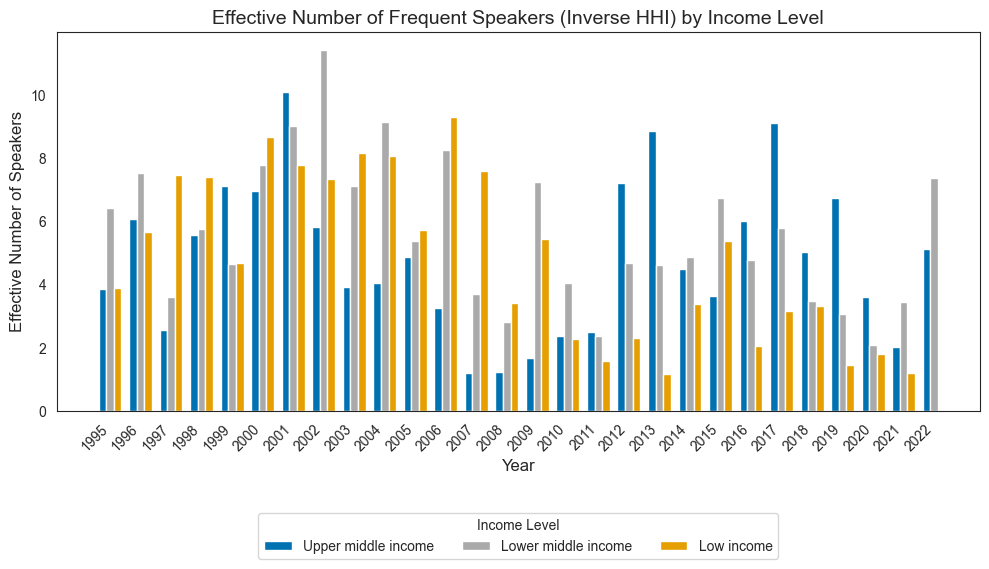

In [24]:

sns.set_style("white")
plt.rcParams['figure.figsize'] = (10, 6)

grayscale_colors = {
    "Upper middle income": "#0072B2",
    "Lower middle income": "#AAAAAA",
    "Low income": "#E69F00"
}

income_order2 = [
    "Upper middle income",
    "Lower middle income",
    "Low income"
]

fig, ax = plt.subplots()

# Filter out High income
exclude_high = hhi_by_income_year[
    hhi_by_income_year['dynamic_income'] != 'High income'
]

# Year axis
years = np.arange(1995, 2023)
x = np.arange(len(years))

bar_width = 0.25

# Plot grouped bars
for i, income in enumerate(income_order2):
    data = exclude_high[exclude_high['dynamic_income'] == income]
    year_avg = data.groupby('year')['inverse_HHI'].mean()

    # Align data to full year range
    values = [year_avg.get(y, np.nan) for y in years]

    ax.bar(
        x + (i - 1) * bar_width,
        values,
        width=bar_width,
        label=income,
        color=grayscale_colors[income]
    )

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=10)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Effective Number of Speakers', fontsize=12)
ax.set_title(
    'Effective Number of Frequent Speakers (Inverse HHI) by Income Level',
    fontsize=14
)

ax.legend(
    title="Income Level",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3
)

ax.grid(False)
ax.tick_params(axis='both', which='both', length=4)

plt.tight_layout()
plt.show()


Quantificiation of our claim of relative increases via a t-test. T-test appropriate here becuase the variable of interest (hhi by income year) is not a count. Inverse-HHI is intepreted as an effective number, but it is not actually an event count.

In [25]:
from scipy import stats

# Define periods based on visual break
pre = hhi_by_income_year['year'] <= 2008
post = hhi_by_income_year['year'] >= 2010

# Test for each income level
for income in ['Low income', 'Lower middle income', 'Upper middle income']:
    data = hhi_by_income_year[hhi_by_income_year['dynamic_income'] == income]
    pre_vals = data[pre]['inverse_HHI']
    post_vals = data[post]['inverse_HHI']
    
    #Welch's t-test (does not assume equal variances)
    stats.ttest_ind(post_vals, pre_vals, equal_var=False)
    
    print(f"{income}:")
    print(f"  Pre-2009: {pre_vals.mean():.2f} (SD={pre_vals.std():.2f})")
    print(f"  Post-2009: {post_vals.mean():.2f} (SD={post_vals.std():.2f})")
    print(f"  t={t_stat:.2f}, p={p_val:.3f}\n")

Low income:
  Pre-2009: 6.79 (SD=1.81)
  Post-2009: 2.43 (SD=1.21)
  t=7.90, p=0.000

Lower middle income:
  Pre-2009: 6.62 (SD=2.46)
  Post-2009: 4.42 (SD=1.57)
  t=7.90, p=0.000

Upper middle income:
  Pre-2009: 4.76 (SD=2.43)
  Post-2009: 5.13 (SD=2.35)
  t=7.90, p=0.000



/var/folders/h0/ghmj50d14v7_1_2mwdw3p0w00000gr/T/ipykernel_57008/2848004367.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre_vals = data[pre]['inverse_HHI']
/var/folders/h0/ghmj50d14v7_1_2mwdw3p0w00000gr/T/ipykernel_57008/2848004367.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  post_vals = data[post]['inverse_HHI']
/var/folders/h0/ghmj50d14v7_1_2mwdw3p0w00000gr/T/ipykernel_57008/2848004367.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre_vals = data[pre]['inverse_HHI']
/var/folders/h0/ghmj50d14v7_1_2mwdw3p0w00000gr/T/ipykernel_57008/2848004367.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  post_vals = data[post]['inverse_HHI']
/var/folders/h0/ghmj50d14v7_1_2mwdw3p0w00000gr/T/ipykernel_57008/2848004367.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre_vals = data[pre]['inverse_HHI']
/var/folder

Quantifying similarity of speaker sets before/after 2007-2009 (visual chokepoint in the data)

In [26]:
# Calculate Jaccard similarity for each income level pre-post 
def jaccard_similarity(set1, set2):
    """Returns similarity from 0 (no overlap) to 1 (identical)"""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

results = []
for income in ['Low income', 'Lower middle income', 'Upper middle income']:
    # Get speakers pre/post
    pre_speakers = set(grouped_all[
        (grouped_all['year'] <= 2008) & 
        (grouped_all['dynamic_income'] == income)
    ]['country'].unique())
    
    post_speakers = set(grouped_all[
        (grouped_all['year'] >= 2010) & 
        (grouped_all['dynamic_income'] == income)
    ]['country'].unique())
    
    jaccard = jaccard_similarity(pre_speakers, post_speakers)
    
    results.append({
        'income_level': income,
        'pre_speakers': len(pre_speakers),
        'post_speakers': len(post_speakers),
        'overlap': len(pre_speakers & post_speakers),
        'jaccard_similarity': jaccard,
        'turnover_rate': 1 - jaccard,
        'pre-speakers': pre_speakers,
        'post-speakrs': post_speakers

    })

pd.DataFrame(results)

,income_level,pre_speakers,post_speakers,overlap,jaccard_similarity,turnover_rate,pre-speakers,post-speakrs
0,Low income,37,19,15,0.365854,0.634146,"{Cameroon, Central African Republic, Kenya, Ne...","{Central African Republic, Kenya, Gambia, The,..."
1,Lower middle income,41,38,19,0.316667,0.683333,"{Namibia, Cuba, Djibouti, Panama, Venezuela, R...","{Cameroon, Kenya, Nepal, Philippines, Papua Ne..."
2,Upper middle income,27,31,12,0.260870,0.739130,"{Croatia, Uruguay, Korea, Rep., St. Kitts and ...","{Uruguay, Cuba, Panama, Venezuela, RB, Dominic..."


Look just at the UMC speaker in the 2007-2008-2009 nadir

In [29]:
# Calculate Jaccard similarity for each income level pre-post 
## use previously defined Jaccard similarity

results_small = []
for income in ['Low income', 'Lower middle income', 'Upper middle income']:
    # Get speakers pre/post
    speakers_2007 = set(grouped_all[
        (grouped_all['year'] == 2007) & 
        (grouped_all['dynamic_income'] == income)
    ]['country'].unique())
    
    speakers_2008= set(grouped_all[
        (grouped_all['year'] == 2008) & 
        (grouped_all['dynamic_income'] == income)
    ]['country'].unique())

    speakers_2009= set(grouped_all[
        (grouped_all['year'] == 2009) & 
        (grouped_all['dynamic_income'] == income)
    ]['country'].unique())

    speakers_2010= set(grouped_all[
        (grouped_all['year'] == 2010) & 
        (grouped_all['dynamic_income'] == income)
    ]['country'].unique())

    speakers_2011= set(grouped_all[
        (grouped_all['year'] == 2011) & 
        (grouped_all['dynamic_income'] == income)
    ]['country'].unique())

    
    results_small.append({
        'income_level': income,
        'len_2007': len(speakers_2007),
        'speakers_2007': speakers_2007,
        'len_2008': len(speakers_2008),
        'speakers_2008': speakers_2008,
        'len_2009': len(speakers_2009),
        'speakers_2009': speakers_2009,
        'len_2010': len(speakers_2010),
        'speakers_2010': speakers_2010,
        'len_2011': len(speakers_2011),
        'speakers_2011': speakers_2011,
    })

pd.DataFrame(results_small)

,income_level,len_2007,speakers_2007,len_2008,speakers_2008,len_2009,speakers_2009,len_2010,speakers_2010,len_2011,speakers_2011
0,Low income,12,"{Zambia, Nigeria, Pakistan, Kenya, Mali, Burki...",8,"{Tanzania, Zambia, Nigeria, Pakistan, Burkina ...",9,"{Zambia, Haiti, Kenya, Burkina Faso, Guinea, N...",4,"{Burkina Faso, Kenya, Bangladesh, Zambia}",2,"{Kenya, Bangladesh}"
1,Lower middle income,6,"{El Salvador, Lesotho, Cuba, Nicaragua, Egypt,...",5,"{El Salvador, Lesotho, Tonga, China, India}",15,"{El Salvador, Iran, Islamic Rep., Lesotho, Jor...",10,"{Vietnam, El Salvador, Honduras, Pakistan, Ecu...",9,"{El Salvador, Lesotho, Nigeria, Pakistan, Fiji..."
2,Upper middle income,2,"{Brazil, Malaysia}",4,"{Costa Rica, Brazil, Mexico, Chile}",5,"{St. Lucia, Mexico, Brazil, Colombia, Chile}",4,"{St. Lucia, Brazil, Venezuela, RB, Dominican R...",11,"{Uruguay, Cuba, Ecuador, Mexico, Panama, Argen..."


Persistence of frequent speakers over time:

In [32]:
# Did the TOP speakers persist?
def top_speaker_persistence(data, income, n_top=5):
    """Check if top N speakers in period 1 remained top N in period 2"""
    
    # Get top speakers pre-2009
    pre = data[(data['year'] <= 2008) & (data['dynamic_income'] == income)]
    pre_totals = pre.groupby('country')['num_turns'].sum().sort_values(ascending=False)
    top_pre = set(pre_totals.head(n_top).index)
    
    # Get top speakers post-2009
    post = data[(data['year'] >= 2010) & (data['dynamic_income'] == income)]
    post_totals = post.groupby('country')['num_turns'].sum().sort_values(ascending=False)
    top_post = set(post_totals.head(n_top).index)
    
    # Calculate persistence
    persisted = len(top_pre & top_post)
    
    return {
        'top_pre': list(top_pre),
        'top_post': list(top_post),
        'persisted': persisted,
        'persistence_rate': persisted / n_top,
        'churned_out': list(top_pre - top_post),
        'churned_in': list(top_post - top_pre)
    }

# Run for each income level
for income in ['Low income', 'Lower middle income', 'Upper middle income']:
    result = top_speaker_persistence(grouped_all, income, n_top=5)
    print(f"\n{income}:")
    print(f"  Persistence: {result['persisted']}/5 ({result['persistence_rate']:.1%})")
    print(f"  Churned out: {result['churned_out']}")
    print(f"  Churned in: {result['churned_in']}")


Low income:
  Persistence: 1/5 (20.0%)
  Churned out: ['Kenya', 'Zambia', 'India', 'Pakistan']
  Churned in: ['Chad', 'Benin', 'Nepal', 'Uganda']

Lower middle income:
  Persistence: 1/5 (20.0%)
  Churned out: ['China', 'Morocco', 'Sri Lanka', 'Cuba']
  Churned in: ['Bangladesh', 'Nigeria', 'Cameroon', 'India']

Upper middle income:
  Persistence: 1/5 (20.0%)
  Churned out: ['Malaysia', 'Mauritius', 'Venezuela, RB', 'Mexico']
  Churned in: ['China', 'Ecuador', 'Cuba', 'South Africa']


In [33]:
## UMC concentration over time:
umc = grouped_all[grouped_all['dynamic_income'] == 'Upper middle income'].copy()
umc['total_by_year'] = umc.groupby('year')['num_turns'].transform('sum')
umc['share'] = umc['num_turns'] / umc['total_by_year']

umc = umc.sort_values(['year', 'share'], ascending=[True, False])
umc['cum_share'] = umc.groupby('year')['share'].cumsum()
# FIX: use prev_cum_share < 0.8 so that years where one country alone exceeds 80%
# are counted as 1 (not dropped). The old filter cum_share <= 0.8 excluded the
# dominant country itself, leaving zero rows for those years and dropping them entirely.
umc_80 = (
    umc[umc.groupby('year')['cum_share'].shift(1, fill_value=0) < 0.8]
    .groupby('year')
    .size()
    .reset_index(name='num_countries_to_80pct')
)


## LMC concentration over time:
lmc = grouped_all[grouped_all['dynamic_income'] == 'Lower middle income'].copy()
lmc['total_by_year'] = lmc.groupby('year')['num_turns'].transform('sum')
lmc['share'] = lmc['num_turns'] / lmc['total_by_year']

lmc = lmc.sort_values(['year', 'share'], ascending=[True, False])
lmc['cum_share'] = lmc.groupby('year')['share'].cumsum()
lmc_80 = (
    lmc[lmc.groupby('year')['cum_share'].shift(1, fill_value=0) < 0.8]
    .groupby('year')
    .size()
    .reset_index(name='num_countries_to_80pct')
)

lmc_80

## LIC concentration over time:
lic = grouped_all[grouped_all['dynamic_income'] == 'Low income'].copy()
lic['total_by_year'] = lic.groupby('year')['num_turns'].transform('sum')
lic['share'] = lic['num_turns'] / lic['total_by_year']

lic = lic.sort_values(['year', 'share'], ascending=[True, False])
lic['cum_share'] = lic.groupby('year')['share'].cumsum()
lic_80 = (
    lic[lic.groupby('year')['cum_share'].shift(1, fill_value=0) < 0.8]
    .groupby('year')
    .size()
    .reset_index(name='num_countries_to_80pct')
)

#lic_80

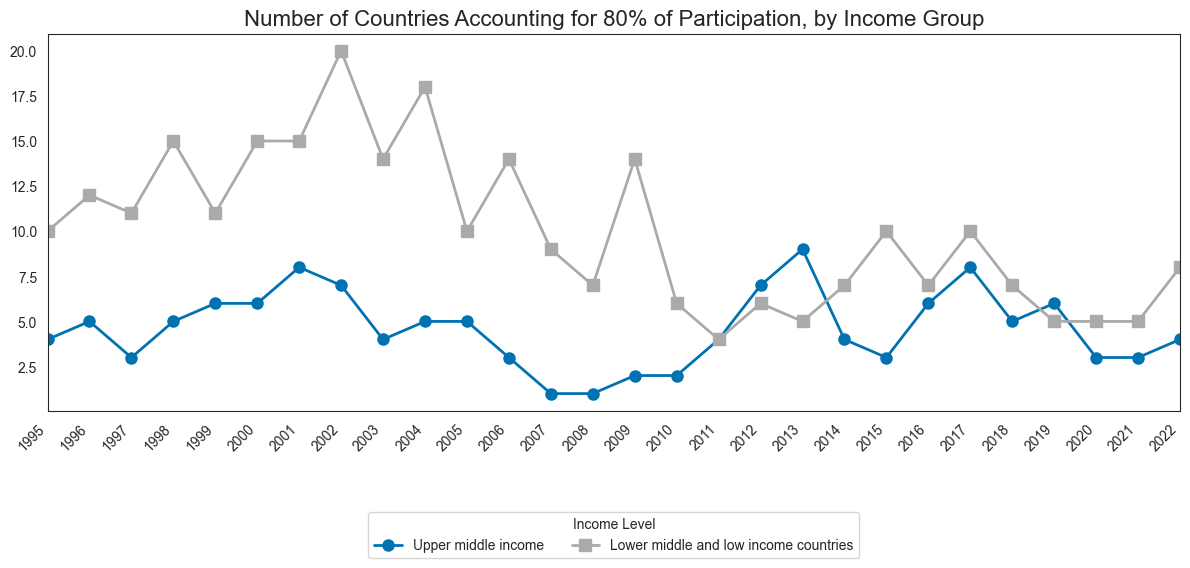

In [34]:
# Define color mapping
plot_colors = {
    "Upper middle income": "#0072B2",  # deep blue
    "Lower/Low income": "#AAAAAA",     # medium gray
}

# Combine LMC and LIC into a single series
combined_80 = (
    pd.concat([lmc_80, lic_80])
    .groupby("year")["num_countries_to_80pct"]
    .sum()
    .reset_index()
)

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Plot UMC (Upper middle income)
ax.plot(
    umc_80["year"], umc_80["num_countries_to_80pct"],
    marker="o", color=plot_colors["Upper middle income"],
    linewidth=2, markersize=8, label="Upper middle income"
)

# Plot combined LMC + LIC
ax.plot(
    combined_80["year"], combined_80["num_countries_to_80pct"],
    marker="s", color=plot_colors["Lower/Low income"],
    linewidth=2, markersize=8, label="Lower middle and low income countries"
)

# Title and labels
ax.set_title(
    "Number of Countries Accounting for 80% of Participation, by Income Group",
    fontsize=16
)

start_year, end_year = 1995, 2022
all_years = list(range(start_year, end_year + 1))

ax.set_xlim(start_year, end_year)
ax.set_xticks(all_years)
plt.xticks(rotation=45, ha="right")
ax.grid(False)
ax.tick_params(axis="both", which="both", length=4)

# Legend
ax.legend(
    title="Income Level",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2
)

plt.tight_layout()

# Optional: save the figure
fig_file = FIGPATH / "countries_to_80pct.png"
plt.savefig(fig_file, dpi=300)

# Display
plt.show()

## Which countries dominate?

In [35]:
umc_top_countries = (
    umc[umc['cum_share'] <= 0.8]
    .groupby('year')['country']
    .apply(list)
    .reset_index(name='countries_to_80pct')
)

print(umc_top_countries)

    year                                 countries_to_80pct
0   1995                   [Argentina, Mexico, Korea, Rep.]
1   1996       [Argentina, Brazil, Czech Republic, Hungary]
2   1997                   [Trinidad and Tobago, Argentina]
3   1998              [Mauritius, Mexico, Barbados, Brazil]
4   1999     [Brazil, Mexico, Korea, Rep., Uruguay, Panama]
5   2000  [Mauritius, Mexico, Barbados, Venezuela, RB, S...
6   2001  [Panama, Argentina, Mexico, Venezuela, RB, Uru...
7   2002  [Costa Rica, Mexico, Malaysia, Barbados, Venez...
8   2003       [Mauritius, Malaysia, Mexico, Venezuela, RB]
9   2004  [Venezuela, RB, Barbados, Malaysia, Trinidad a...
10  2005  [Malaysia, Costa Rica, Antigua and Barbuda, Ar...
11  2006                              [Malaysia, Argentina]
12  2009                                           [Brazil]
13  2010                                [Brazil, St. Lucia]
14  2011                              [China, Cuba, Jordan]
15  2012  [China, Cuba, Ecuador, Argenti

In [ ]:
print(len(umc[umc['year']==2009])) #5 speakers
print(umc[umc['year']==2009].head(10))

: 

In [ ]:
## But is this China becoming UMC?

lmc_top_countries = (
    lmc[lmc['cum_share'] <= 0.8]
    .groupby('year')['country']
    .apply(list)
    .reset_index(name='countries_to_80pct')
)

print(lmc_top_countries)

: 

## Expectation 2: Representing others


In [36]:
## Idenfity if/when 'on behalf of' is mentioned
## take out non-state actors:

behalf_of = states.copy()
behalf_of['paratext_lower'] = behalf_of['paratext'].str.lower() #ensure lower cased

## Column for the target, NaN if nothing:
behalf_of['behalf_target'] = behalf_of['paratext_lower'].str.extract(
    r'on behalf of\s+(.*?)(?:[\.,;]|$)',  # stops at period/comma/semicolon or end
    expand=False
)

# Binary column for whether there is a 'behalf of' match:
behalf_of['behalf_of'] = behalf_of['behalf_target'].notna()  # True if 'behalf_target' is not NaN



In [37]:
behalf_by_income_year = (
    behalf_of[behalf_of['behalf_of']]
    .groupby(['year', 'dynamic_income'])
    .size()
    .reset_index(name='obf') #obf = on behalf of
)

print(behalf_by_income_year.head(10))

   year       dynamic_income  obf
0  1995          High income    2
1  1995           Low income    5
2  1995  Lower middle income    1
3  1995  Upper middle income    4
4  1996          High income    1
5  1996           Low income    2
6  1996  Lower middle income    3
7  1996  Upper middle income    1
8  1997          High income    1
9  1997           Low income    4


In [38]:
## prepare to plot:
pivot_df2 = behalf_by_income_year.pivot(index='year', 
                                         columns='dynamic_income', 
                                         values='obf').fillna(0)
print(pivot_df2)

dynamic_income  High income  Low income  Lower middle income  \
year                                                           
1995                    2.0         5.0                  1.0   
1996                    1.0         2.0                  3.0   
1997                    1.0         4.0                  0.0   
1998                    0.0         5.0                  2.0   
1999                    1.0         0.0                  0.0   
2000                    2.0         4.0                  1.0   
2001                    0.0         2.0                  0.0   
2002                    1.0         9.0                  5.0   
2003                    1.0         9.0                  1.0   
2004                    0.0         1.0                  4.0   
2005                    0.0         0.0                  4.0   
2006                    0.0        20.0                  6.0   
2007                    0.0         3.0                  7.0   
2008                    4.0         0.0 

Table: supports claim that lower income states tend to use "on behalf of" more often than UMC.

Design:  Data are count data with lots of zeros, which means that t-test is mispecified (assumes normality with continuous and symmetric data). Designing our comparision as a regression with one categorical predictor is analagous to an ANOVA test with the correct distributional form for the data generating process (variable = count of behavior). Our model aggregates participation at the level of income grouping (upper middle income, etc) rather than the state delegation level. We cluster standard errors at the year level to account for temporal dependencies in the data. (We do not cluster at income level, because the year and income level aggregation results in too few observations for inference.) 

For our comparison, we aggregate counts to the year × income-level , resulting in 108 observations (27 years × 4 income levels). Standard errors are clustered by year (27 clusters) to account for within-year correlation across income levels due to shared institutional context. 

In [39]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula='obf ~ C(dynamic_income, Treatment(reference="Upper middle income"))',
    data=behalf_by_income_year,
    family=sm.families.NegativeBinomial()
)

# Cluster SE by year:
result = model.fit(
    cov_type='cluster',
    cov_kwds={'groups': behalf_by_income_year['year']})

## Modify the results print out to accept exponenitated IRR and SE:

# Create interpretable output table
results_table = pd.DataFrame({
    'Coefficient': result.params,
    'Std. Error (clustered)': result.bse,
    'IRR': np.exp(result.params),
    '95% CI Lower': np.exp(result.conf_int()[0]),
    '95% CI Upper': np.exp(result.conf_int()[1]),
    'z-value': result.tvalues,
    'p-value': result.pvalues
})

/Users/Promachos/Dropbox (Personal)/WTO-Github/WTO-DataRelease/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Format for appendix

In [40]:
results_table = pd.DataFrame({
    'Variable': result.params.index,
    'Coefficient': result.params.values,
    'Std. Error': result.bse.values,
    'IRR': np.exp(result.params.values),
    '95% CI': [f"({np.exp(result.conf_int()[0].iloc[i]):.2f}, {np.exp(result.conf_int()[1].iloc[i]):.2f})" 
               for i in range(len(result.params))],
    'z': result.tvalues.values,
    'p-value': result.pvalues.values
})

# Clean up variable names for readability
def clean_var_name(name):
    if 'Intercept' in name:
        return 'Intercept (Upper middle income)'
    elif 'High income' in name:
        return 'High income'
    elif 'Low income' in name:
        return 'Low income'
    elif 'Lower middle income' in name:
        return 'Lower middle income'
    return name

results_table['Variable'] = results_table['Variable'].apply(clean_var_name)

# Add significance stars
def add_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.10:
        return '†'
    return ''

results_table['Sig.'] = results_table['p-value'].apply(add_stars)

# Format numeric columns
results_table['Coefficient'] = results_table['Coefficient'].apply(lambda x: f"{x:.3f}")
results_table['Std. Error'] = results_table['Std. Error'].apply(lambda x: f"{x:.3f}")
results_table['IRR'] = results_table['IRR'].apply(lambda x: f"{x:.2f}")
results_table['z'] = results_table['z'].apply(lambda x: f"{x:.2f}")
results_table['p-value'] = results_table['p-value'].apply(lambda x: f"{x:.3f}")

# Reorder columns for presentation
table_final = results_table[['Variable', 'Coefficient', 'Std. Error', 'IRR', '95% CI', 'z', 'p-value', 'Sig.']]

# Option 1: Print nicely formatted for copy-paste
print("="*100)
print("Table A1: Negative Binomial Model - 'On Behalf Of' Speaker-Turns by Income Level")
print("="*100)
print(table_final.to_string(index=False))
print("\n" + "="*100)
print("Model Statistics:")
print(f"  N observations: {int(result.nobs)}")
print(f"  N clusters (years): {behalf_by_income_year['year'].nunique()}")
print(f"  Log-Likelihood: {result.llf:.2f}")
print(f"  AIC: {result.aic:.2f}")
print(f"  BIC: {result.bic:.2f}")
print(f"  Dispersion: {result.scale:.3f}")
print("="*100)
print("\nNotes: Reference category: Upper middle income states")
print("Standard errors clustered by year")
print("IRR = Incidence Rate Ratio (exponentiated coefficient)")
print("† p<0.10, * p<0.05, ** p<0.01, *** p<0.001")

Table A1: Negative Binomial Model - 'On Behalf Of' Speaker-Turns by Income Level
                       Variable Coefficient Std. Error  IRR       95% CI     z p-value Sig.
Intercept (Upper middle income)       0.960      0.180 2.61 (1.84, 3.71)  5.34   0.000  ***
                    High income      -0.104      0.158 0.90 (0.66, 1.23) -0.66   0.511     
                     Low income       0.846      0.233 2.33 (1.48, 3.68)  3.63   0.000  ***
            Lower middle income       0.183      0.194 1.20 (0.82, 1.76)  0.94   0.346     

Model Statistics:
  N observations: 80
  N clusters (years): 28
  Log-Likelihood: -189.75
  AIC: 387.51
  BIC: -305.97
  Dispersion: 1.000

Notes: Reference category: Upper middle income states
Standard errors clustered by year
IRR = Incidence Rate Ratio (exponentiated coefficient)
† p<0.10, * p<0.05, ** p<0.01, *** p<0.001


/Users/Promachos/Dropbox (Personal)/WTO-Github/WTO-DataRelease/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [41]:

# Generate and save
html_output = create_regression_table_html(result, behalf_by_income_year)

output_path = 'table_a1_onbehalf.html'
with open(output_path, 'w') as f:
    f.write(html_output)

print(f"Table saved to: {output_path}")


Table saved to: table_a1_onbehalf.html


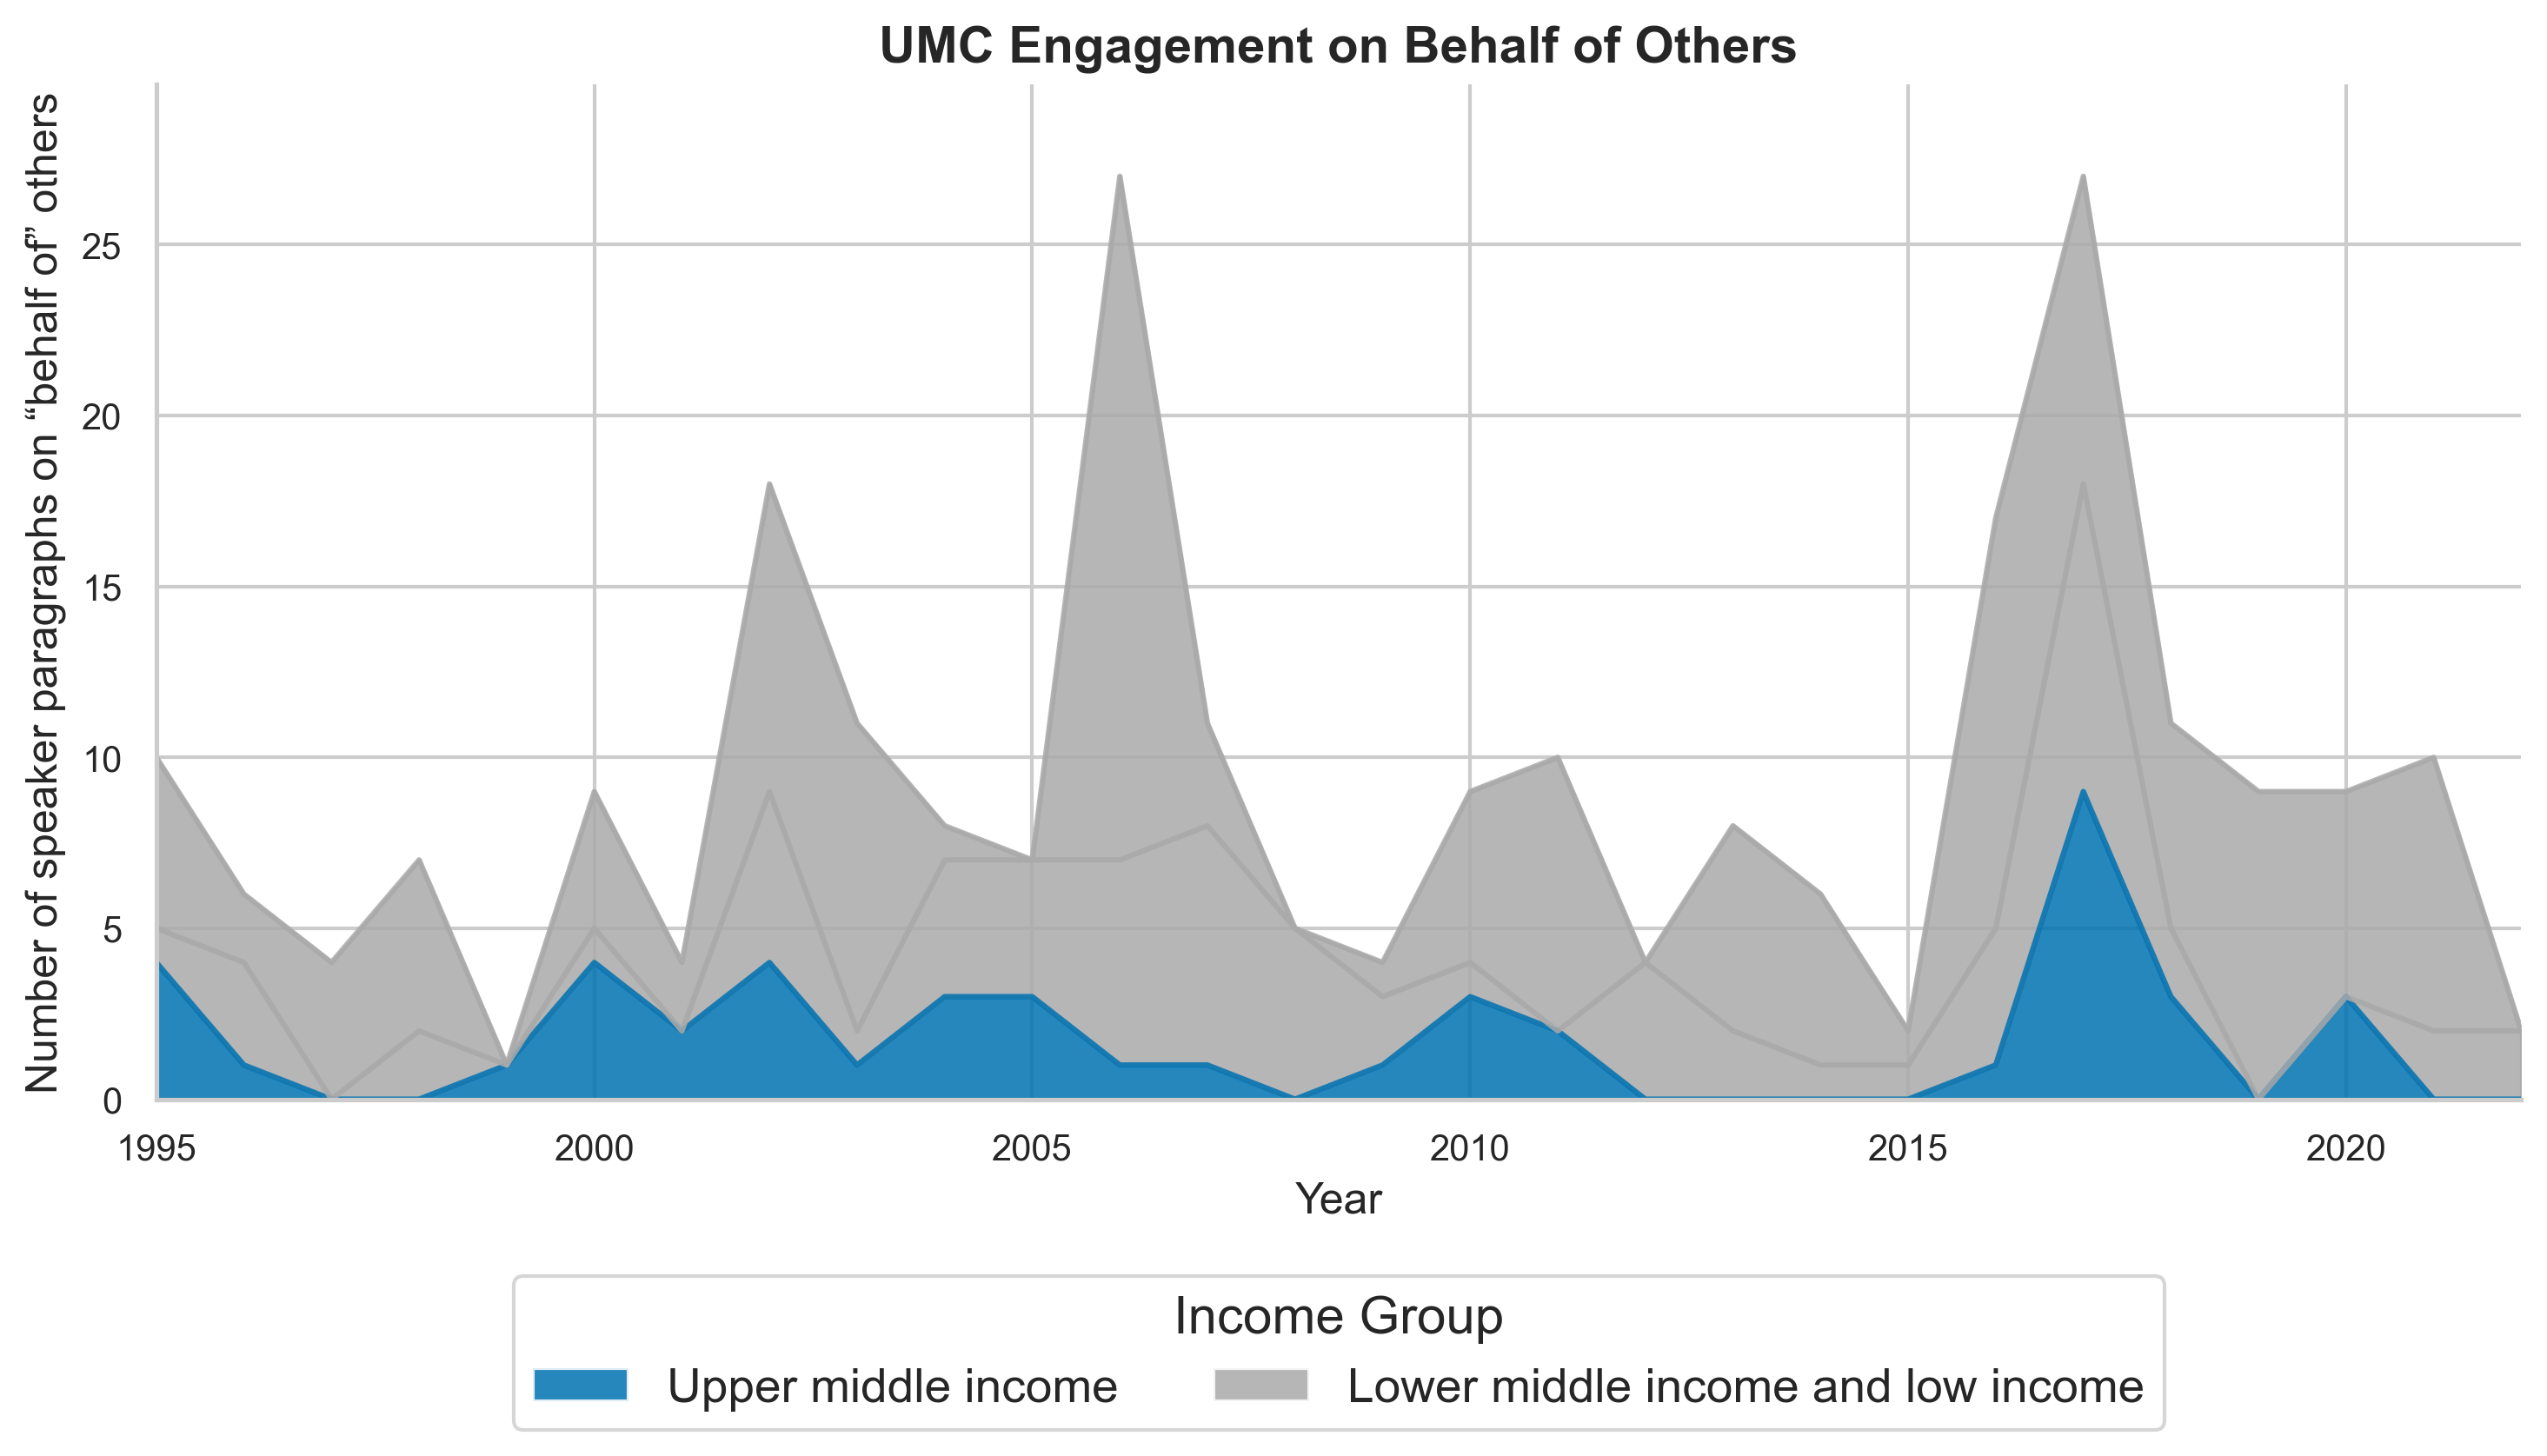

In [42]:
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.pyplot as plt

## Plot: only UMC vs LMC and LIC, grouped

sns.set(style="whitegrid", font_scale=1.2, rc={"figure.dpi": 300})

# Use a colorblind-friendly palette
grayscale_colors = {
    "High income": "#111111",         # near black
    "Upper middle income": "#0072B2",
    "Lower middle income": "#AAAAAA",
    "Low income": "#AAAAAA"
}

# Order of groups for consistent stacking
income_order = [
    "Upper middle income",
    "Lower middle income",
    "Low income"
]

# Sort and reindex the pivoted dataframe for consistency
# Use reindex so missing income groups become 0 rather than raising KeyError
pivot_df2 = pivot_df2.reindex(columns=income_order, fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

pivot_df2.plot.area(
    ax=ax,
    color=[grayscale_colors[i] for i in income_order],
    alpha=0.85
)

# Titles and labels
ax.set_title(
    'UMC Engagement on Behalf of Others',
    fontsize=14,
    weight='bold'
)

ax.set_xlabel('Year', fontsize=12)

ax.set_ylabel(
    'Number of speaker paragraphs on “behalf of” others',
    fontsize=12
)

# Custom legend handles
legend_handles = [
    Patch(
        facecolor="#0072B2",
        alpha=0.85,
        label="Upper middle income"
    ),
    Patch(
        facecolor="#AAAAAA",
        alpha=0.85,
        label="Lower middle income and low income"
    )
]

# Legend
ax.legend(
    handles=legend_handles,
    title='Income Group',
    loc='center',
    bbox_to_anchor=(0.5, -0.25),
    borderaxespad=0.0,
    ncol=2
)

# Tick formatting
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xlim(
    pivot_df2.index.min(),
    pivot_df2.index.max()
)

ax.set_ylim(
    0,
    pivot_df2.sum(axis=1).max() * 1.1
)

# Remove spines for clean aesthetic
sns.despine()

# Tight layout for saving
plt.tight_layout()

# Save in high-res format
plt.savefig(FIGPATH / 'proposal_mentions_by_income.png')

plt.show()

In [43]:
del behalf_of

## Expectation 3: Documents Leadership


Note: the code identifying the most active documents (proposals) is in our development script:

High level:
#wt/comtd/w/192    190-china-egypt-india
#wt/comtd/w/175    128-china-egypt-india
#wt/comtd/w/208    116-china-egypt-india
#wt/comtd/w/104     60- 2003 technical assistance plan
#wt/comtd/w/204     30- circa 2019 Secretariat record-keeping
#wt/comtd/w/66    

In [44]:
proposals = states.copy()
proposals['paratext_lower'] = proposals['paratext'].str.lower().fillna('')

In [46]:
# Background: quantify number of references to different proposals
def extract_proposals(text):
    if pd.isna(text):
        return []
    return re.findall(r'(?:wt/)?comtd/w/(\d+)', text.lower())

# Apply extraction
proposals['proposal_ids'] = proposals['paratext'].map(extract_proposals)

# --- Step 2: Flatten all proposal IDs into one list ---
all_ids = [pid for sublist in proposals['proposal_ids'] for pid in sublist if sublist]

# --- Step 3: Count occurrences of each proposal ID (robust across pandas versions) ---
proposal_counts = (
    pd.Series(all_ids)
    .value_counts()
    .reset_index()
    .rename(columns=lambda x: 'proposal_id' if x == 'index' else 'mention_count')
    .sort_values(by='mention_count', ascending=False)
)

# --- Step 4: Preview top proposals ---
print(proposal_counts.head(10))


  proposal_id  mention_count
0         192            103
1         175             64
2         208             63
3         104             28
4         191             13
5         143             12
6          66             12
7          15             11
8         202             10
9         204              8


In [47]:
# --- How many unique proposals exist, and how concentrated are mentions? ---
n_unique = proposal_counts['proposal_id'].nunique()
total_mentions = proposal_counts['mention_count'].sum()

proposal_counts['cum_pct'] = proposal_counts['mention_count'].cumsum() / total_mentions * 100

print(f'Unique proposals mentioned: {n_unique}')
print(f'Total mentions: {total_mentions}')
print()
print('Proposals needed to reach coverage thresholds:')
for threshold in [50, 75, 80, 90]:
    n = (proposal_counts['cum_pct'] <= threshold).sum() + 1
    print(f'  {threshold}%: top {n} proposals')
print()
print('Cumulative coverage for top N proposals:')
print(proposal_counts[['proposal_id', 'mention_count', 'cum_pct']].head(15).round(1).to_string(index=False))

Unique proposals mentioned: 92
Total mentions: 542

Proposals needed to reach coverage thresholds:
  50%: top 6 proposals
  75%: top 24 proposals
  80%: top 30 proposals
  90%: top 47 proposals

Cumulative coverage for top N proposals:
proposal_id  mention_count  cum_pct
        192            103     19.0
        175             64     30.8
        208             63     42.4
        104             28     47.6
        191             13     50.0
        143             12     52.2
         66             12     54.4
         15             11     56.5
        202             10     58.3
        204              8     59.8
         73              8     61.3
         69              8     62.7
        101              8     64.2
         72              7     65.5
        224              7     66.8


In [48]:
# --- Count total proposal references (all IDs) ---
proposals['all_comtd_refs'] = proposals['paratext_lower'].str.count(r'wt/comtd/w/\w+')

# --- Count individual proposals (raw frequency, not boolean) ---
proposals['p192_mentions'] = proposals['paratext_lower'].str.count(r'wt/comtd/w/192')
proposals['p208_mentions'] = proposals['paratext_lower'].str.count(r'wt/comtd/w/208')
proposals['p175_mentions'] = proposals['paratext_lower'].str.count(r'wt/comtd/w/175')
proposals['p104_mentions'] = proposals['paratext_lower'].str.count(r'wt/comtd/w/104')
proposals['p204_mentions'] = proposals['paratext_lower'].str.count(r'wt/comtd/w/204')
proposals['p66_mentions']  = proposals['paratext_lower'].str.count(r'wt/comtd/w/66')

# --- Aggregate by year ---
top_proposals_stats = (
    proposals
    .groupby('year')
    .agg(
        all_comtd_refs=('all_comtd_refs', 'sum'),
        p192_mentions=('p192_mentions', 'sum'),
        p208_mentions=('p208_mentions', 'sum'),
        p175_mentions=('p175_mentions', 'sum'),
        p104_mentions=('p104_mentions', 'sum'),
        p204_mentions=('p204_mentions', 'sum'),
        p66_mentions=('p66_mentions', 'sum')
    )
    .reset_index()
)

# --- Sanity check: sum of top-6 vs total ---
top_cols = ['p192_mentions','p208_mentions','p175_mentions','p104_mentions','p204_mentions','p66_mentions']

# Add the stack_sum column if it doesn't exist
if 'stack_sum' not in top_proposals_stats.columns:
    top_proposals_stats['stack_sum'] = top_proposals_stats[top_cols].sum(axis=1)

# Sanity check: sum of top 6 proposals
# vs all proposals
check = top_proposals_stats[['year', 'stack_sum', 'all_comtd_refs']].copy()
print(check.round(3).tail(20))

    year  stack_sum  all_comtd_refs
8   2003          1              18
9   2004          0               9
10  2005          0              19
11  2006          0               5
12  2007          0               5
13  2008          0               1
14  2009          0               4
15  2010          0               0
16  2011          1               7
17  2012          3              11
18  2013         23              40
19  2014         13              23
20  2015          8               9
21  2016         27              33
22  2017         41              57
23  2018         58              61
24  2019         21              21
25  2020          8               8
26  2021         28              31
27  2022          7              10


In [49]:
# --- Coverage: what share of all proposal mentions do the top 6 account for? ---
check['top6_pct'] = (check['stack_sum'] / check['all_comtd_refs'].replace(0, float('nan'))) * 100

overall_pct = check['stack_sum'].sum() / check['all_comtd_refs'].sum() * 100

print('Year-by-year coverage of top 6 documents (% of all mentions):')
print(check[['year', 'top6_pct']].round(1).to_string(index=False))
print()
print(f'Overall (pooled): {overall_pct:.1f}% of all wt/comtd/w/* mentions')
print(f'Annual mean:      {check["top6_pct"].mean():.1f}%')
print(f'Annual range:     {check["top6_pct"].min():.1f}% – {check["top6_pct"].max():.1f}%')

Year-by-year coverage of top 6 documents (% of all mentions):
 year  top6_pct
 1995       0.0
 1996       0.0
 1997       0.0
 1998       0.0
 1999       0.0
 2000      24.5
 2001       0.0
 2002      64.3
 2003       5.6
 2004       0.0
 2005       0.0
 2006       0.0
 2007       0.0
 2008       0.0
 2009       0.0
 2010       NaN
 2011      14.3
 2012      27.3
 2013      57.5
 2014      56.5
 2015      88.9
 2016      81.8
 2017      71.9
 2018      95.1
 2019     100.0
 2020     100.0
 2021      90.3
 2022      70.0

Overall (pooled): 51.5% of all wt/comtd/w/* mentions
Annual mean:      35.1%
Annual range:     0.0% – 100.0%


In [50]:
proposal_by_income_year = (
    proposals
    .groupby(['year', 'dynamic_income'])['all_comtd_refs']
    .sum()
    .reset_index(name='proposal_mentions')
)

## add a binary for after 2010:

proposal_by_income_year['post_2010'] = (
    proposal_by_income_year['year'] >= 2010
).astype(int)

# Pivot to year × income matrix for plotting
pivot_df = (
    proposal_by_income_year
    .pivot(index='year', columns='dynamic_income', values='proposal_mentions')
    .fillna(0)
    .sort_index()
)

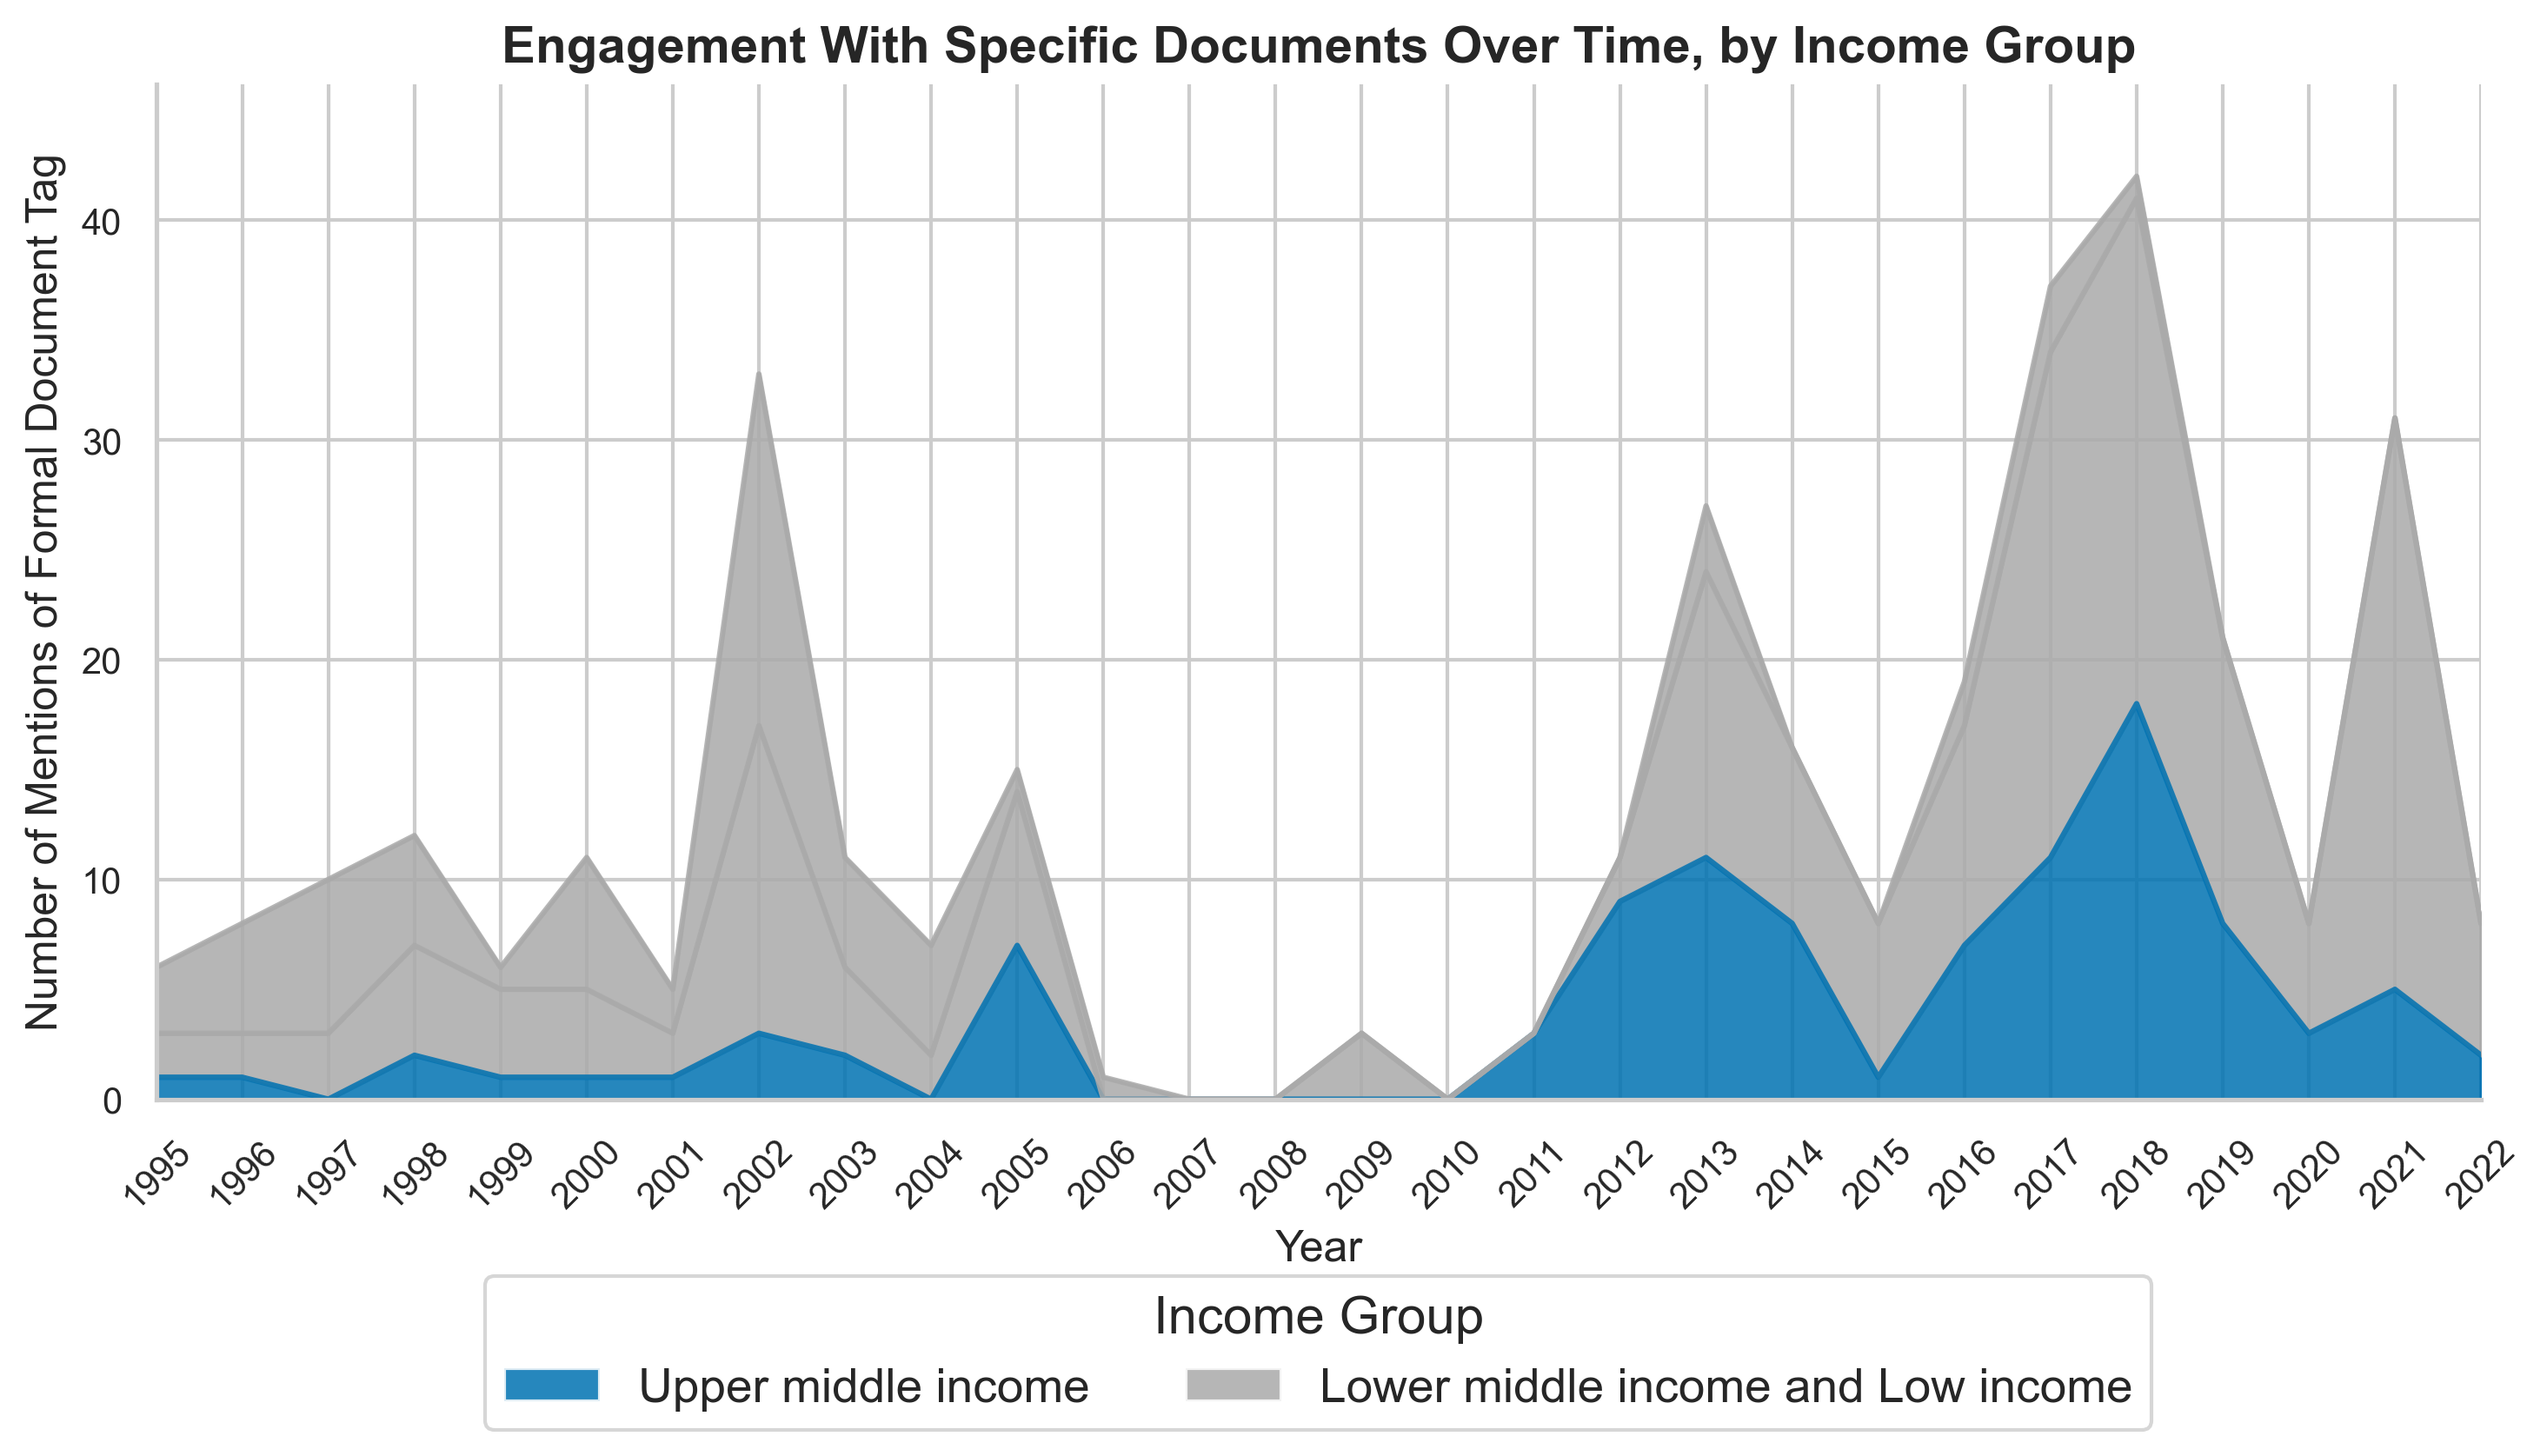

In [51]:
## Income year:
## basic style

sns.set(style="whitegrid", font_scale=1.2, rc={"figure.dpi": 300})

# Use a colorblind-friendly palette
grayscale_colors = {
    "Upper middle income": "#0072B2",
    "Lower middle income": "#AAAAAA",
    "Low income": "#AAAAAA",
}

# Order of groups for consistent stacking
income_order2 = [
    "Upper middle income",
    "Lower middle income",
    "Low income"
]

# Sort and reindex the pivoted dataframe for consistency
pivot_df = pivot_df[income_order2].fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

pivot_df.plot.area(
    ax=ax,
    color=[grayscale_colors[i] for i in income_order2],
    alpha=0.85
)

# Titles and labels
ax.set_title(
    'Engagement With Specific Documents Over Time, by Income Group',
    fontsize=14,
    weight='bold'
)

ax.set_xlabel('Year', fontsize=12)

ax.set_ylabel(
    'Number of Mentions of Formal Document Tag',
    fontsize=12
)

# Custom legend handles
legend_handles = [
    Patch(
        facecolor="#0072B2",
        alpha=0.85,
        label="Upper middle income"
    ),
    Patch(
        facecolor="#AAAAAA",
        alpha=0.85,
        label="Lower middle income and Low income"
    )
]

# Legend
ax.legend(
    handles=legend_handles,
    title='Income Group',
    loc='center',
    bbox_to_anchor=(0.5, -0.25),
    borderaxespad=0.0,
    ncol=2
)

# Tick formatting
ax.tick_params(axis='both', which='major', labelsize=10)

ax.set_xticks(pivot_df.index)  # one tick per year
ax.set_xticklabels(pivot_df.index, rotation=45)

ax.set_xlim(
    pivot_df.index.min(),
    pivot_df.index.max()
)

ax.set_ylim(
    0,
    pivot_df.sum(axis=1).max() * 1.1
)

# Remove spines for clean aesthetic
sns.despine()

# Tight layout for saving
plt.tight_layout()

# Save in high-res format
plt.savefig(FIGPATH /'proposal_mentions_by_income_1.png')

plt.show()

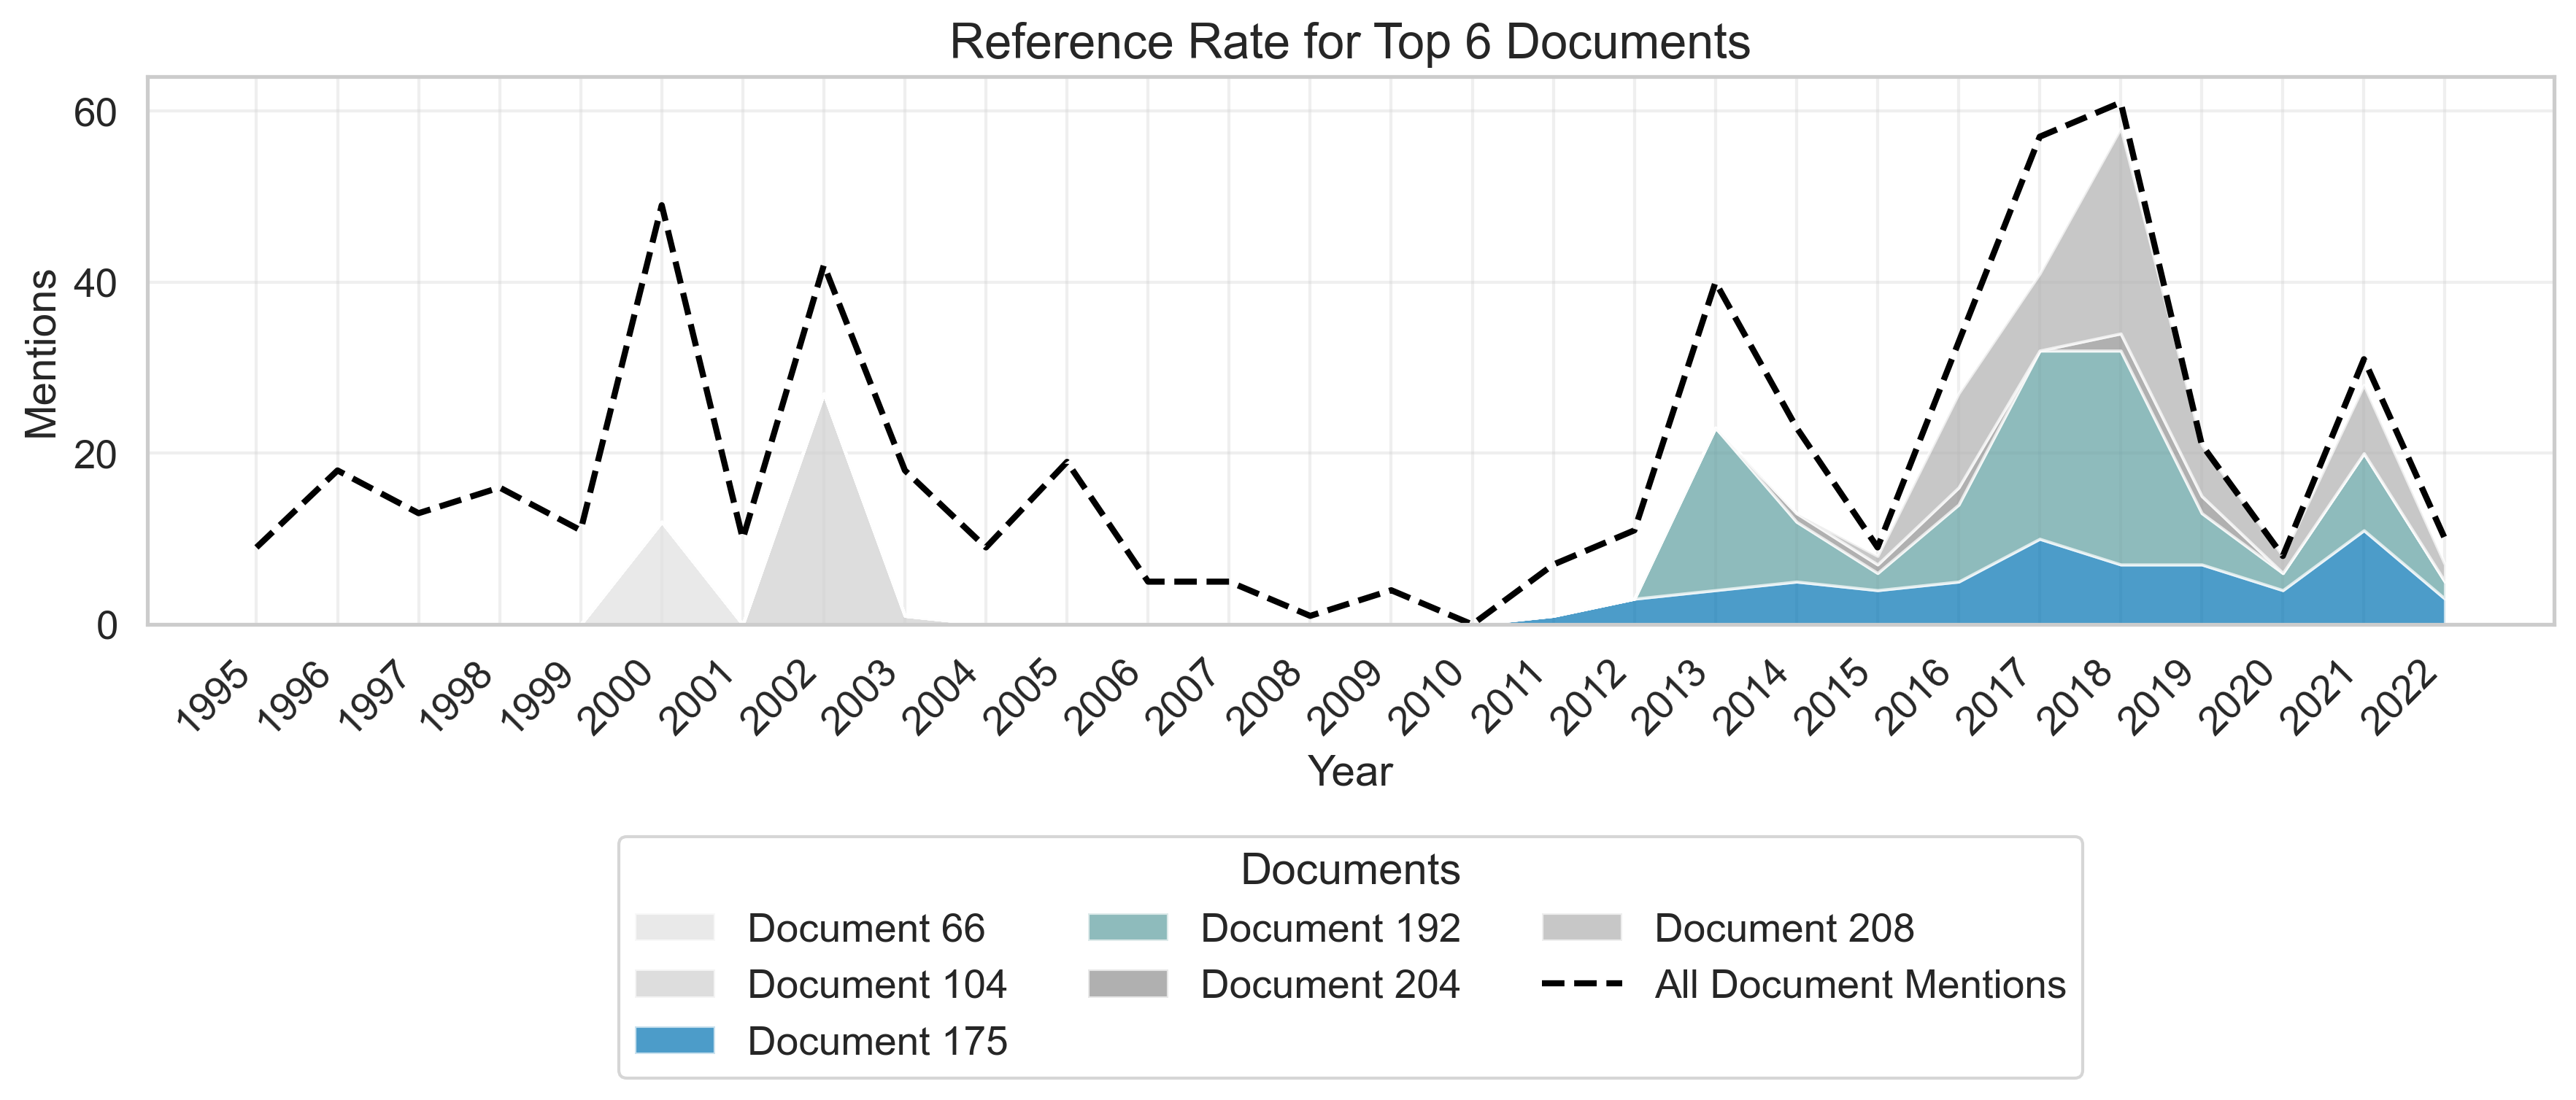

In [ ]:
# --- Color palette ---
proposal_colors = [
    "#E0E0E0",  # pale gray
    "#CFCFCF",  # light gray
    "#0072B2",  # deep blue
    "#5F9EA0",  # muted teal
    "#8F8F8F",  # mid-gray
    "#B0B0B0",  # light gray
]

# --- Labels matching your dataframe columns ---
label_map = {
    'p66_mentions': 'Document 66',
    'p104_mentions': 'Document 104',
    'p175_mentions': 'Document 175',
    'p192_mentions': 'Document 192',
    'p204_mentions': 'Document 204',
    'p208_mentions': 'Document 208'
}

# --- Column order for stackplot ---
y_columns = [
    'p66_mentions', 'p104_mentions', 
    'p175_mentions', 'p192_mentions', 
    'p204_mentions', 'p208_mentions'
]

# --- Create the stacked area chart ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    top_proposals_stats['year'],
    [top_proposals_stats[col] for col in y_columns],
    labels=[label_map[col] for col in y_columns],
    colors=proposal_colors,
    alpha=0.7
)

# --- Dashed line for all proposals (from all_comtd_refs) ---
ax.plot(
    top_proposals_stats['year'],
    top_proposals_stats['all_comtd_refs'],
    color='black',
    linewidth=2,
    linestyle='--',
    label='All Document Mentions'
)

# --- Style and labels ---
ax.set_title("Reference Rate for Top 6 Documents", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_xticks(top_proposals_stats['year'])  # one tick per year
ax.set_xticklabels(top_proposals_stats['year'], rotation=45)
ax.set_ylabel("Mentions", 
              fontsize=14)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, 
           ha='right')

# --- Legend ---
ax.legend(
    title="Documents",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.35),
    ncol=3
)

plt.tight_layout()
plt.savefig(FIGPATH / 'stacked_proposals_mentions_fixed.png', dpi=300)
plt.show()


Appendix: quantitative support for different levels of engagement with documents, with Upper middle income as the reference. Negative binomial model because count with relatively many zeros

In [ ]:
model = smf.glm(
    formula="""
        proposal_mentions
        ~ C(dynamic_income, Treatment(reference="Upper middle income"))
        * post_2010
    """,
    data=proposal_by_income_year,
    family=sm.families.NegativeBinomial()
)

# Cluster SE by year, matching the "on behalf of" model (cell 53)
result = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": proposal_by_income_year["year"]}
)

print(result.summary())
## exponentiate for interpretability:
# Report exponentiated coefficient (IRR) with p-values from the raw model.
print(np.exp(result.params))

: 